In [1]:
# Import Statements (General)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
# Import ML-Relevant Packages
import xgboost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.tree import export_graphviz
from IPython.display import Image
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import seaborn as sns
from skopt import BayesSearchCV
import graphviz
import time

In [72]:
# Import Data
p45_60_box = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_60_min_shock_box.csv")
p45_60_hc = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_60_min_shock_hc.csv")
p45_15_box = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_15_min_shock_box.csv")
p45_15_hc = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_15_min_shock_hc.csv")

# Strict
p45_60_box_strict = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_60_min_shock_box_strict.csv")


In [26]:
# Define Feature Groups
binding = ['n_clusters_x', 'total_ReadCount', 'mean_ModeScore']
regions = ['frac_utr3','frac_intron']
all = ['n_clusters_x', 'total_ReadCount', 'mean_ModeScore', 'frac_utr3','frac_intron', 'frac_utr5', 'frac_cds']
(p45_60_box['Expression'] == 0)

0       True
1       True
2       True
3       True
4       True
        ... 
2234    True
2235    True
2236    True
2237    True
2238    True
Name: Expression, Length: 2239, dtype: bool

In [5]:
# Outlier Remover
class IQROutlierDetection(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=1.5):
        self.threshold = threshold
    
    def fit(self, X, y=None):
        # Calculate IQR for each column
        self.iqr_ = np.percentile(X, 75, axis=0) - np.percentile(X, 25, axis=0)
        self.lower_bound_ = np.percentile(X, 25, axis=0) - self.threshold * self.iqr_
        self.upper_bound_ = np.percentile(X, 75, axis=0) + self.threshold * self.iqr_
        return self
    
    def transform(self, X):
        # Replace outliers with NaN (anything outside the IQR bounds)
        X_transformed = X.copy()
        for i in range(X.shape[1]):
            outlier_mask = (X[:, i] < self.lower_bound_[i]) | (X[:, i] > self.upper_bound_[i])
            X_transformed[outlier_mask, i] = np.nan
        return X_transformed
    

In [50]:
# Hyperparameters
params = {"objective": "binary:logistic", "tree_method": "gpu_hist"}

In [63]:
# Pipeline
pipeline = Pipeline([
    ('scaler', MinMaxScaler()), # TODO: Why MinMaxScaler()?
    ('outlier_remover', IQROutlierDetection()),
    ('imputer', KNNImputer()),
    ('classifier', XGBClassifier(objective='binary:logistic',
                                 eval_metric='auc',
                                 random_state=42,
                                 scale_pos_weight=4
                                 ))
])

xgb = XGBClassifier

# Isolation forests require training per fold.
# Also, hyperparameter tune per cv.
# Cloning - or else the model will keep a copy of the tests. Instead of cloning the model, you clone the hyperparameters shallow copy. Shallow vs. Deep copy.
# Start with XGBoost.
# Robert thinks the first issue I'll have is with isolation.

In [ ]:
from skopt.space import Real, Integer

search_space = {
    "classifier__n_estimators": Integer(200, 1200),
    "classifier__learning_rate": Real(1e-2, 2e-1, prior="log-uniform"),
    "classifier__max_depth": Integer(2, 8),
    "classifier__min_child_weight": Integer(1, 15),
    "classifier__subsample": Real(0.5, 1.0),
    "classifier__colsample_bytree": Real(0.5, 1.0),
    "classifier__gamma": Real(0.0, 5.0),
    "classifier__reg_alpha": Real(1e-8, 10.0, prior="log-uniform"),
    "classifier__reg_lambda": Real(1e-3, 50.0, prior="log-uniform"),
}

bayes = BayesSearchCV(
    estimator=pipeline,
    search_spaces=search_space,
    n_iter=40,              # bump to 80+ if you can afford it
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True,
)

bayes.fit(X_array, y)

print("Best CV ROC AUC:", bayes.best_score_)
print("Best params:", bayes.best_params_)
best_model = bayes.best_estimator_

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [65]:
# K Folds
n_splits = 5
skf = KFold(n_splits=n_splits, random_state = 42, shuffle=True)
X_array = p45_60_box[all].to_numpy()
y = p45_60_box['Expression']
data_splits_objects = skf.split(X_array,y)

In [66]:
# empty lists to capture the pred and exp
predicted_y = []
expected_y = []
fprs = []
tprs = []

# Fit iteratively
count = 0
for train_index, test_index in skf.split(X_array, y):
    
    count +=1
    X_train = X_array[train_index]
    X_test  = X_array[test_index]
    y_train = y[train_index]
    y_test  = y[test_index]
    X_train = pd.DataFrame(X_train)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    predicted_y.extend(y_pred)
    expected_y.extend(y_test)
    accuracy = accuracy_score(y_test, y_pred) 
    conf_m = confusion_matrix(y_test, y_pred)

    print("---------------------------------------------")
    print(f"Summary for validation {count}/{n_splits}:")
    #Display the accuracy
    print(f'Accuracy: {accuracy:.2f}')
    # Get ROC Metric
    y_pred_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test,  y_pred_prob)
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f'AUC: {auc}')
    fprs.append(fpr)
    tprs.append(tpr)

---------------------------------------------
Summary for validation 1/5:
Accuracy: 0.68
AUC: 0.5355598628298791
---------------------------------------------
Summary for validation 2/5:
Accuracy: 0.69
AUC: 0.49337715855573
---------------------------------------------
Summary for validation 3/5:
Accuracy: 0.67
AUC: 0.5129229245750123
---------------------------------------------
Summary for validation 4/5:
Accuracy: 0.66
AUC: 0.4885969615728329
---------------------------------------------
Summary for validation 5/5:
Accuracy: 0.67
AUC: 0.43361244019138756


In [54]:
# Hyperparameter Tuning (BayesSearchCV)
rf = xgb(random_state=42, n_jobs=-1)

search = BayesSearchCV(rf, param_dist, n_iter = 30, cv = 5, scoring = 'roc_auc',
                       refit = False, verbose = 1)

search.fit(X_train, y_train)

print('Best hyperparameters:',  search.best_params_)
print('Best Estimater:', search.best_estimator_)
print('Best grid hyperparameters:',  search.best_params_)
print('Best grid Estimater:',search.best_estimator_)

ValueError: Invalid dimension 100. See the documentation of check_dimension for supported values.

In [37]:
# Hyperparameter Tuning (GridSearchCV)
rf = xgb(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
  rf, param_grid=param_dist,
  cv=5, scoring='accuracy',
  n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best hyperparameters:',  grid_search.best_params_)
print('Best Estimater:', grid_search.best_estimator_)
print('Best grid hyperparameters:',  grid_search.best_params_)
print('Best grid Estimater:',grid_search.best_estimator_)

NameError: name 'GridSearchCV' is not defined

Total k-fold accuracy = 77.03125%


/var/folders/4y/9yl3btzn7r7b7xfvfw2_74t80000gn/T/ipykernel_73112/1373233743.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=4)


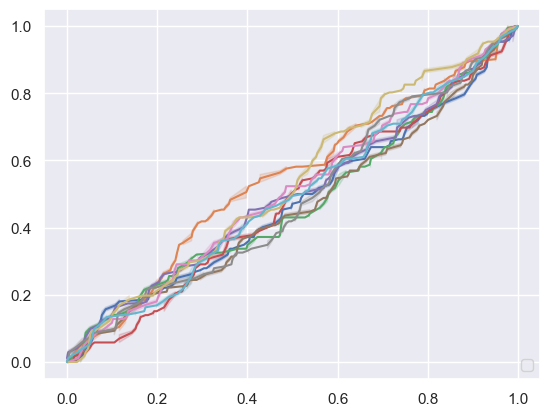

In [28]:
# Plot Data
accuracy = accuracy_score(expected_y,predicted_y)
print(f"Total k-fold accuracy = {accuracy * 100}%")
param_dist = {
  'n_estimators': 100,
  'max_depth': 10,
  'min_samples_split': 5,
  'min_samples_leaf': 2
}
data_res = [fprs,tprs]
# plt.figure()
sns.set_theme(style="darkgrid")
for i in range(len(fprs)):
    sns.lineplot(data=pd.DataFrame(fprs[i],tprs[i]), x=fprs[i],y=tprs[i])
    # sns.title(f'Reciever Operator Characteristics (ROC): AUC = {auc}')
    # plt.xlabel('False Positive Rate (FPR)')
    # plt.ylabel('True Positive Rate (FPR)')
    # sns.plot([0,1], ls='--')
plt.legend(loc=4)
plt.show()

/var/folders/4y/9yl3btzn7r7b7xfvfw2_74t80000gn/T/ipykernel_73112/2135331946.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


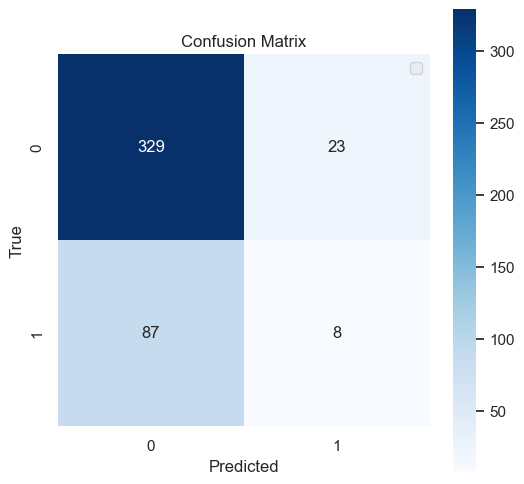

In [53]:
# Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_m, annot=True, fmt="d", cmap="Blues", cbar=True, square=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# -----------------------------
# Inputs you must set
# -----------------------------
X_df= p45_60_box_strict 
y = p45_60_box_strict ['Expression']

feature_cols = [
'n_clusters_x', 'total_ReadCount', 'mean_ModeScore', 'frac_utr3','frac_intron', 'frac_utr5', 'frac_cds'
]

# Define Feature Groups

# -----------------------------
# CV setup
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# Baseline model (LogReg)
# -----------------------------
# Scaling helps for logistic regression; class_weight helps imbalance.
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        solver="liblinear",
        random_state=42
    ))
])

# -----------------------------
# A) All-features AUC
# -----------------------------
X_all = X_df[feature_cols].to_numpy()
y_arr = np.asarray(y)

auc_all = cross_val_score(logreg_pipe, X_all, y_arr, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"[LogReg | ALL 7] ROC AUC = {auc_all.mean():.4f} ± {auc_all.std():.4f}")

# -----------------------------
# B) One-feature AUC audit
# -----------------------------
results = []
for col in feature_cols:
    X_1 = X_df[[col]].to_numpy()
    auc_1 = cross_val_score(logreg_pipe, X_1, y_arr, cv=cv, scoring="roc_auc", n_jobs=-1)
    results.append({
        "feature": col,
        "auc_mean": float(auc_1.mean()),
        "auc_std": float(auc_1.std())
    })

res_df = pd.DataFrame(results).sort_values("auc_mean", ascending=False)
print("\n[LogReg | ONE-FEATURE AUDIT]")
print(res_df.to_string(index=False))

# -----------------------------
# C) Optional: Intronic vs 3'UTR subset test
# -----------------------------
# If you know the exact column names for intron and 3'UTR features, plug them here:
subset_cols = [
   'frac_intron', 'frac_utr3'
]
if len(subset_cols) > 0:
    X_sub = X_df[subset_cols].to_numpy()
    auc_sub = cross_val_score(logreg_pipe, X_sub, y_arr, cv=cv, scoring="roc_auc", n_jobs=-1)
    print(f"\n[LogReg | SUBSET {subset_cols}] ROC AUC = {auc_sub.mean():.4f} ± {auc_sub.std():.4f}")

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=5000))
])

pipe.fit(X_df[["n_clusters_x"]], y_arr)

coef = pipe.named_steps["clf"].coef_[0][0]
print("Coefficient:", coef)



[LogReg | ALL 7] ROC AUC = 0.4842 ± 0.0117

[LogReg | ONE-FEATURE AUDIT]
        feature  auc_mean  auc_std
total_ReadCount  0.526055 0.045951
 mean_ModeScore  0.514897 0.025178
      frac_utr5  0.501258 0.006405
       frac_cds  0.496046 0.013031
   n_clusters_x  0.495976 0.055970
    frac_intron  0.493653 0.024284
      frac_utr3  0.488087 0.011649

[LogReg | SUBSET ['frac_intron', 'frac_utr3']] ROC AUC = 0.4896 ± 0.0209
Coefficient: 0.031960092814741645


In [75]:
import numpy as np

# get predicted probabilities
probs = pipe.predict_proba(X_df[["n_clusters_x"]])[:, 1]

print("Mean prob UP when high clusters:",
      probs[X_df["n_clusters_x"] > X_df["n_clusters_x"].median()].mean())

print("Mean prob UP when low clusters:",
      probs[X_df["n_clusters_x"] <= X_df["n_clusters_x"].median()].mean())

Mean prob UP when high clusters: 0.5043241777718789
Mean prob UP when low clusters: 0.495936206964121
